### 📝 Task info:
**Farmer Segmentation using Clustering (Unsupervised Learning)**
- **Objective:** Segment smallholder farmers based on demographic, agricultural productivity, financial status, and resource usage patterns to enable targeted agricultural interventions.
- **Dataset:** 240,000+ smallholder household records stored in MySQL Agriculture Database (`agricultural.agricultural_productivity`).

### 💻 Code Work:

In [1]:
# Base Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML Libraries for Clustering & Preprocessing
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.metrics import silhouette_score

# Database Connection
from sqlalchemy import create_engine, inspect
from urllib.parse import quote_plus
import warnings
warnings.filterwarnings('ignore')

### 📤 0. Data Loading (from db load tables data as pandas df)
- Note: Load Validated Data

In [2]:
USER = "root"
PASSWORD = quote_plus("Annapurneswaraiah@403") 
HOST = "127.0.0.1" 
PORT = "3306"
DATABASE = "agricultural"

connection_url = f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DATABASE}"

try:
    engine = create_engine(connection_url)
    inspector = inspect(engine)
    tables = inspector.get_table_names()
    print("Available tables in MySQL:", tables)

    if len(tables) > 0:
        table_name = tables[0] 
        print(f"\nLoading data from MySQL table: '{table_name}'...")
        df = pd.read_sql(f"SELECT * FROM `{table_name}`", con=engine)
        print(f"Success! Loaded {df.shape[0]:,} rows and {df.shape[1]} columns.")
    else:
        raise ValueError("No tables found in MySQL database.")
except Exception as e:
    print(f"MySQL Load Notice ({e}). Loading from local dataset...")
    df = pd.read_csv("agricultural_productivity_Cleaned.csv")
    print(f"Loaded {df.shape[0]:,} rows and {df.shape[1]} columns.")

display(df.head())

Available tables in MySQL: ['agricultural_productivity', 'raw_agricultural_productivity_cleaned_v7.csv']

Loading data from MySQL table: 'agricultural_productivity'...
Success! Loaded 240,000 rows and 117 columns.


,record_id,state,lga,year,season,household_id,household_size,head_of_household_age,head_of_household_sex,head_of_household_education_level,...,group_type,access_to_improved_technologies,government_subsidy_received,subsidy_type,extension_worker_visit_last_6months,labor_hours_per_week_agriculture,hired_labor_used,women_decision_making_in_agriculture,child_labor_in_agriculture,child_labor_hours_per_week
0,1,Kebbi,Ogun_LGA_1,2018,wet,1,8,36.151305,Male,Unknown,...,No_group,0,0,None,0,20.684387,0,0,0,0.000000
1,2,Zamfara,Plateau_LGA_10,2018,wet,1,2,59.818008,Female,Unknown,...,No_group,0,0,None,1,12.296398,0,1,0,0.000000
2,3,Anambra,Rivers_LGA_9,2018,wet,1,9,57.055866,Male,Unknown,...,No_group,1,0,None,1,60.305280,0,1,1,0.412805
3,4,Sokoto,Lagos_LGA_8,2018,wet,1,6,54.137561,Female,Tertiary,...,No_group,0,0,None,0,59.165103,1,0,0,0.000000
4,5,Kebbi,Benue_LGA_4,2018,wet,1,11,57.980842,Female,Unknown,...,Association,1,0,None,0,8.739638,0,0,0,0.000000


### 👩🏻‍💻 1. Modeling

#### 🛠️ 1.1 Pre-Requisites
(Entire data will be considered as X)

In [3]:
# Drop metadata / unique identifier columns
X = df.copy()
id_cols = ['record_id', 'household_id']
X = X.drop(columns=[col for col in id_cols if col in X.columns], errors='ignore')

print("Shape of X before preprocessing:", X.shape)

Shape of X before preprocessing: (240000, 115)


#### 🔄 1.1.1 Missing Values & Outliers Handling

In [4]:
# Separate numerical and categorical columns
num_cols = X.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Handle Missing Values
for col in num_cols:
    if X[col].isnull().sum() > 0:
        X[col].fillna(X[col].median(), inplace=True)

for col in cat_cols:
    if X[col].isnull().sum() > 0:
        X[col].fillna(X[col].mode()[0], inplace=True)

# Outlier Handling using IQR capping (1.5 * IQR)
for col in num_cols:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    X[col] = np.clip(X[col], lower_bound, upper_bound)

print("Missing values remaining in X:", X.isnull().sum().sum())

Missing values remaining in X: 0


#### ⚙️ 1.1.2 Feature Engineering
- **Feature Selection (Mandatory) :**
    - For Clustering algos suggested pure numeric cols
        - If cat cols need to select according to business then encoding suggested
- **Feature Generation** (if required)
- **Feature Modification:** Data Pre-Processing of x cols 
    - **Encoding :** Converting cat cols to numerical
        - If binary categories present in col, then apply binary encoding
        - If more than two categories, Ordinal Encoding
    - **Scaling :** Conversion of pure numeric cols under one scale (Mandatory)

In [5]:
# 1. Categorical Encoding (Binary Encoding & Ordinal Encoding)
binary_cat_cols = [col for col in cat_cols if X[col].nunique() == 2]
multi_cat_cols = [col for col in cat_cols if X[col].nunique() > 2]

print(f"Binary Categorical Columns ({len(binary_cat_cols)}): {binary_cat_cols[:5]}")
print(f"Multi-class Categorical Columns ({len(multi_cat_cols)}): {multi_cat_cols[:5]}")

X_encoded = X.copy()

# Apply Binary Encoding for binary categories
for col in binary_cat_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])

# Apply Ordinal Encoding for multi-class categories
if len(multi_cat_cols) > 0:
    ord_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_encoded[multi_cat_cols] = ord_encoder.fit_transform(X_encoded[multi_cat_cols])

# 2. Select numerical & encoded features for Clustering
feature_cols = num_cols + binary_cat_cols + multi_cat_cols
X_selected = X_encoded[feature_cols]

# 3. Scaling (StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

print("Scaled Feature Matrix Shape:", X_scaled.shape)

Binary Categorical Columns (3): ['season', 'head_of_household_sex', 'urban_rural']
Multi-class Categorical Columns (17): ['state', 'lga', 'head_of_household_education_level', 'farming_system', 'land_tenure_type']
Scaled Feature Matrix Shape: (240000, 115)


#### 🤖 1.2 Model + Define, Train & Study
- Algorithms to Focus: **K-Means**
- Loading model through python sklearn module
- Define, fit & predict -> Each Row Assigned Group Number

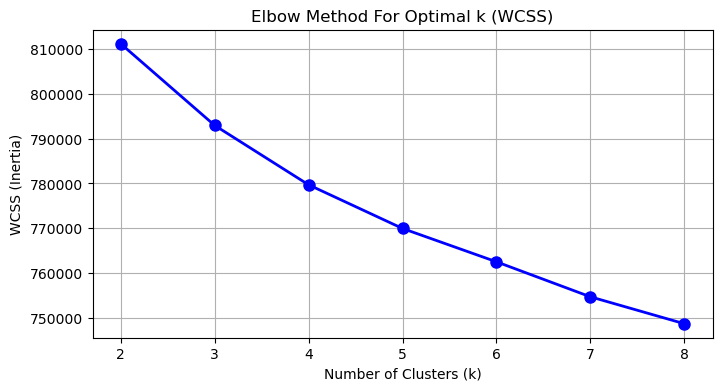

✅ K-Means Model Defined & Trained with 4 Clusters!


In [6]:
# Determine Optimal Number of Clusters (Elbow Method / WCSS)
wcss = []
k_range = range(2, 9)

# Sample data for fast Elbow computation if dataset is large
sample_size = min(10000, X_scaled.shape[0])
sample_idx = np.random.choice(X_scaled.shape[0], sample_size, replace=False)
X_sample = X_scaled[sample_idx]

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_sample)
    wcss.append(kmeans_temp.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(k_range, wcss, 'bo-', linewidth=2, markersize=8)
plt.title('Elbow Method For Optimal k (WCSS)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()

# Define, Fit & Predict K-Means Model (Optimal Clusters k=4)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
group_numbers = kmeans.fit_predict(X_scaled)

print(f"✅ K-Means Model Defined & Trained with {optimal_k} Clusters!")

#### ✅ 1.3 Adding predictions to Original Data
- Above predictions added as a column to main data

In [7]:
# Add group number prediction column to original dataframe
df['Cluster'] = group_numbers
df['Farmer_Segment'] = [f'Group_{g}' for g in group_numbers]

print("Cluster Assignments Count:")
print(df['Cluster'].value_counts().sort_index())
display(df.head())

Cluster Assignments Count:
Cluster
0    60171
1    64866
2    55236
3    59727
Name: count, dtype: int64


,record_id,state,lga,year,season,household_id,household_size,head_of_household_age,head_of_household_sex,head_of_household_education_level,...,government_subsidy_received,subsidy_type,extension_worker_visit_last_6months,labor_hours_per_week_agriculture,hired_labor_used,women_decision_making_in_agriculture,child_labor_in_agriculture,child_labor_hours_per_week,Cluster,Farmer_Segment
0,1,Kebbi,Ogun_LGA_1,2018,wet,1,8,36.151305,Male,Unknown,...,0,None,0,20.684387,0,0,0,0.000000,2,Group_2
1,2,Zamfara,Plateau_LGA_10,2018,wet,1,2,59.818008,Female,Unknown,...,0,None,1,12.296398,0,1,0,0.000000,1,Group_1
2,3,Anambra,Rivers_LGA_9,2018,wet,1,9,57.055866,Male,Unknown,...,0,None,1,60.305280,0,1,1,0.412805,0,Group_0
3,4,Sokoto,Lagos_LGA_8,2018,wet,1,6,54.137561,Female,Tertiary,...,0,None,0,59.165103,1,0,0,0.000000,3,Group_3
4,5,Kebbi,Benue_LGA_4,2018,wet,1,11,57.980842,Female,Unknown,...,0,None,0,8.739638,0,0,0,0.000000,0,Group_0


#### 📥 1.4 Saving groups & Study
- Save above group number added data to csv/excel
- group wise stats
    - Once group number added to row, then filter rows based on group number

In [8]:
# 1. Save group number added data to CSV
output_csv = "clustered_farmers_data.csv"
df.to_csv(output_csv, index=False)
print(f"💾 Clustered data saved to '{output_csv}'!")

# 2. Group-Wise Statistics
key_indicators = [c for c in ['land_owned_hectares', 'fertilizer_used_kg_per_hectare', 
                             'total_household_income_ngn', 'agricultural_income_ngn', 
                             'market_access_distance_km', 'food_consumption_score'] if c in df.columns]

if key_indicators:
    group_stats = df.groupby('Farmer_Segment')[key_indicators].mean().round(2)
    print("\n--- Group-Wise Stats (Mean Values) ---")
    display(group_stats)

# 3. Filter rows based on group number and study each group
for g in sorted(df['Cluster'].unique()):
    group_df = df[df['Cluster'] == g]
    print(f"\n📌 Group {g} Profiling (Total Farmers: {len(group_df):,}):")
    for col in key_indicators:
        print(f"   - Mean {col}: {group_df[col].mean():,.2f}")

💾 Clustered data saved to 'clustered_farmers_data.csv'!

--- Group-Wise Stats (Mean Values) ---


,land_owned_hectares,fertilizer_used_kg_per_hectare,total_household_income_ngn,agricultural_income_ngn,market_access_distance_km,food_consumption_score
Farmer_Segment,,,,,,
Group_0,2.00,50.17,747934.01,598108.78,14.92,45.09
Group_1,2.00,50.24,639679.90,490036.22,15.02,44.99
Group_2,1.98,49.52,638418.98,488397.74,14.93,44.95
Group_3,1.99,50.00,538827.90,389377.79,14.95,44.87



📌 Group 0 Profiling (Total Farmers: 60,171):
   - Mean land_owned_hectares: 2.00
   - Mean fertilizer_used_kg_per_hectare: 50.17
   - Mean total_household_income_ngn: 747,934.01
   - Mean agricultural_income_ngn: 598,108.78
   - Mean market_access_distance_km: 14.92
   - Mean food_consumption_score: 45.09

📌 Group 1 Profiling (Total Farmers: 64,866):
   - Mean land_owned_hectares: 2.00
   - Mean fertilizer_used_kg_per_hectare: 50.24
   - Mean total_household_income_ngn: 639,679.90
   - Mean agricultural_income_ngn: 490,036.22
   - Mean market_access_distance_km: 15.02
   - Mean food_consumption_score: 44.99

📌 Group 2 Profiling (Total Farmers: 55,236):
   - Mean land_owned_hectares: 1.98
   - Mean fertilizer_used_kg_per_hectare: 49.52
   - Mean total_household_income_ngn: 638,418.98
   - Mean agricultural_income_ngn: 488,397.74
   - Mean market_access_distance_km: 14.93
   - Mean food_consumption_score: 44.95

📌 Group 3 Profiling (Total Farmers: 59,727):
   - Mean land_owned_hectares: